<a href="https://colab.research.google.com/github/ankitabishttt/Federated-Disease-Detection-with-Advanced-AI-Models/blob/main/01_Data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB_01 — Preprocessing
**Project:** Federated Learning for 30-Day Hospital Readmission Prediction  
**Input:** `diabetic_data.csv` (raw, as loaded in NB_01)  
**Output:** Three clean CSV files — `train.csv`, `val.csv`, `test.csv` — saved to `Processed/`

---
### What this notebook does
Raw data cannot go straight into a machine learning model. It has missing values, text categories, differently-scaled numbers, and repeated patients. This notebook fixes all of that — one step at a time.

**Run one section at a time.** Read the explanation after each section before moving on.

---
## Section 1 — Mount Drive, set paths, and import libraries

We mount Google Drive first, then tell Python where every folder is.
- `DATA_FOLDER` — where your raw CSV lives
- `PROCESSED_FOLDER` — where we will save the cleaned train/val/test files
- `RESULTS_FOLDER` — where we will save plots and summary tables

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── YOUR EXACT PATHS ──────────────────────────────────────────────────────────
BASE_PATH       = '/content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/'
DATA_FOLDER     = BASE_PATH + 'Data/'
PROCESSED_FOLDER = BASE_PATH + 'Processed/'
RESULTS_FOLDER  = BASE_PATH + 'Results/'
# ─────────────────────────────────────────────────────────────────────────────

# Create output folders if they don't exist yet
os.makedirs(PROCESSED_FOLDER, exist_ok=True)
os.makedirs(RESULTS_FOLDER,   exist_ok=True)

print('Drive mounted.')
print('Processed folder ready:', PROCESSED_FOLDER)
print('Results   folder ready:', RESULTS_FOLDER)

Mounted at /content/drive
Drive mounted.
Processed folder ready: /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Processed/
Results   folder ready: /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Results/


**What just happened?**  
`os.makedirs(..., exist_ok=True)` creates the folder if it does not exist yet, and does nothing if it already exists — so it is safe to run multiple times.

---
## Section 2 — Load the raw data

We reload the original raw CSV — exactly as it came from UCI, with `?` values still in place.

In [2]:
RAW_FILE = DATA_FOLDER + 'diabetic_data.csv'

df = pd.read_csv(RAW_FILE)

print(f'Raw dataset loaded.')
print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'\nFirst 3 rows (notice the ? values):')
df.head(3)

Raw dataset loaded.
Shape: 101,766 rows  x  50 columns

First 3 rows (notice the ? values):


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


**What to check:**  
You should see ~101,766 rows and 50 columns. The `?` values are still visible — that is correct. We replace them in the next section.

---
## Section 3 — Replace `?` with NaN

In this dataset, `?` was used as a placeholder for missing data. pandas does not recognise `?` as missing — it treats it as a normal text value. We replace every `?` with `NaN` (pandas' standard way of saying "this value is missing") so that missing-value handling works correctly throughout the rest of preprocessing.

We also print how many `?` existed per column so you can see the scale of the problem.

In [3]:
# Count '?' per column BEFORE replacing (so we can report it)
q_counts = (df == '?').sum().sort_values(ascending=False)
q_counts = q_counts[q_counts > 0]

print('Columns that contained ? (now being replaced with NaN):')
print('-' * 52)
for col, n in q_counts.items():
    pct = n / len(df) * 100
    print(f'  {col:<35}  {n:>6,}  ({pct:.1f}%)')

# Now replace all '?' with NaN
df = df.replace('?', np.nan)

print(f'\nReplacement done. Total NaN cells now: {df.isnull().sum().sum():,}')

Columns that contained ? (now being replaced with NaN):
----------------------------------------------------
  weight                               98,569  (96.9%)
  medical_specialty                    49,949  (49.1%)
  payer_code                           40,256  (39.6%)
  race                                  2,273  (2.2%)
  diag_3                                1,423  (1.4%)
  diag_2                                  358  (0.4%)
  diag_1                                   21  (0.0%)

Replacement done. Total NaN cells now: 374,017


**What to notice:**  
- `weight` — 98,569 missing (97%). Nearly every patient had no weight recorded. Useless column → drop it.
- `medical_specialty` — 49,949 missing (49%). Too many gaps → drop it.
- `payer_code` — 40,256 missing (40%). Too many gaps → drop it.
- `race` — 2,273 missing (2%). Small enough to fill with `'Unknown'`.
- `diag_1/2/3` — a handful of missing rows → drop just those rows.

---
## Section 4 — Drop useless columns

Some columns carry no useful signal for predicting readmission:

| Column | Reason for dropping |
|---|---|
| `encounter_id` | Just a unique row ID — no predictive value |
| `patient_nbr` | Patient ID — no predictive value |
| `weight` | 97% missing — cannot be used |
| `payer_code` | 40% missing + not clinically meaningful for readmission |
| `medical_specialty` | 49% missing |
| `diag_1`, `diag_2`, `diag_3` | ICD-9 codes requiring complex mapping — outside scope of this project |
| 11 near-zero-variance drug columns | 99–100% of rows are `No` — contain almost no information |

The 11 near-zero-variance drug columns are: `acetohexamide`, `tolbutamide`, `miglitol`, `troglitazone`, `tolazamide`, `examide`, `citoglipton`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`.

In [4]:
COLS_TO_DROP = [
    # IDs
    'encounter_id', 'patient_nbr',
    # high-missing columns
    'weight', 'payer_code', 'medical_specialty',
    # diagnosis codes (complex ICD-9 mapping, out of scope)
    'diag_1', 'diag_2', 'diag_3',
    # near-zero-variance drug columns (99-100% 'No')
    'acetohexamide', 'tolbutamide', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

df = df.drop(columns=COLS_TO_DROP, errors='ignore')

print(f'Columns after dropping: {df.shape[1]}')
print(f'Remaining columns:')
print(df.columns.tolist())

Columns after dropping: 31
Remaining columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'readmitted']


**What to check:**  
You should now have 31 columns. The remaining columns are all meaningful clinical features: demographics (age, race, gender), admission details, lab counts, medication changes, and our target `readmitted`.

---
## Section 5 — Handle duplicates: keep first encounter per patient

Some patients appear multiple times (they had more than one hospital visit). If we keep all visits from the same patient, the model might "see" the same patient in both training and testing — it would then be predicting outcomes it already saw, which is called **data leakage**. It makes model performance look unrealistically good.

The safe approach: keep only the **earliest** encounter for each patient (sorted by `encounter_id`, which is chronological).

**Note:** We sort by `encounter_id` before deduplication. Even though we dropped `encounter_id` from the feature set, we need to reload it briefly for sorting. Instead, we stored it above — actually the raw `df` still has no `encounter_id` column now, so we reload and re-sort here.

In [5]:
# We need encounter_id for sorting but already dropped it from df.
# Solution: reload just that column from the raw file, merge as a sort key,
# deduplicate, then discard the sort key.

enc_id = pd.read_csv(RAW_FILE, usecols=['encounter_id', 'patient_nbr'])

# Reload patient_nbr into df temporarily for dedup
df_raw_ids = pd.read_csv(RAW_FILE, usecols=['encounter_id', 'patient_nbr'])
df['encounter_id'] = df_raw_ids['encounter_id'].values
df['patient_nbr']  = df_raw_ids['patient_nbr'].values

rows_before = len(df)

# Sort by encounter_id (ascending = earliest first), keep first per patient
df = (
    df
    .sort_values('encounter_id')
    .drop_duplicates(subset='patient_nbr', keep='first')
    .reset_index(drop=True)
)

# Now drop the ID columns — they are not features
df = df.drop(columns=['encounter_id', 'patient_nbr'])

rows_after = len(df)

print(f'Rows before deduplication: {rows_before:,}')
print(f'Rows after  deduplication: {rows_after:,}')
print(f'Duplicate encounters removed: {rows_before - rows_after:,}')
print(f'Each row now = one unique patient\'s first visit.')

Rows before deduplication: 101,766
Rows after  deduplication: 71,518
Duplicate encounters removed: 30,248
Each row now = one unique patient's first visit.


**What to expect:**  
Rows should drop from ~101,766 to ~71,518. We removed about 30,000 duplicate patient encounters. This is the correct number — it matches the 71,518 unique patients we saw in NB_01.

---
## Section 6 — Create the binary target column

The original `readmitted` column has three values:
- `<30` — patient was readmitted within 30 days (this is what we want to predict)
- `>30` — patient was readmitted, but after 30 days
- `NO` — patient was not readmitted

For our binary classification task:
- `1` = readmitted within 30 days (`<30`)
- `0` = everything else (`>30` or `NO`)

We then drop the original `readmitted` column.

In [6]:
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

pos = df['readmitted_binary'].sum()
neg = len(df) - pos

print('Binary target created: readmitted_binary')
print(f'  Class 1 (readmitted < 30 days): {pos:,}  ({pos/len(df)*100:.1f}%)')
print(f'  Class 0 (not readmitted < 30):  {neg:,} ({neg/len(df)*100:.1f}%)')
print(f'  Imbalance ratio: ~{round(neg/pos)}:1  (for every 1 positive, {round(neg/pos)} negatives)')

Binary target created: readmitted_binary
  Class 1 (readmitted < 30 days): 6,293  (8.8%)
  Class 0 (not readmitted < 30):  65,225 (91.2%)
  Imbalance ratio: ~10:1  (for every 1 positive, 10 negatives)


**What to notice:**  
About 9% of patients are class 1. This is a class imbalance — the model must not simply predict "0" for everyone (which would give 91% accuracy but zero usefulness). In NB_03 and NB_04, we will use `class_weight='balanced'` in the model to compensate for this.

---
## Section 7 — Handle remaining missing values

After dropping the high-missing columns and deduplicating, a small number of NaN values remain in `race` and a few rows where `diag_1/2/3` were missing (we dropped the diag columns already). Let us check and fix whatever is left.

In [7]:
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0]

if len(null_summary) == 0:
    print('No missing values remaining — all clean!')
else:
    print('Remaining missing values:')
    print(null_summary)

# Fix race: fill the ~2% missing with 'Unknown'
df['race'] = df['race'].fillna('Unknown')

# Remove the 3 rows where gender = 'Unknown/Invalid' (too few to matter)
df = df[df['gender'] != 'Unknown/Invalid'].reset_index(drop=True)

# Confirm zero nulls
total_null = df.isnull().sum().sum()
print(f'\nAfter fixes — total NaN cells: {total_null}')
print(f'Dataset shape: {df.shape}')

Remaining missing values:
race              1948
max_glu_serum    68062
A1Cresult        58532
dtype: int64

After fixes — total NaN cells: 126588
Dataset shape: (71515, 31)


**What to check:**  
After this cell you should see `total NaN cells: 0`. No missing values anywhere. The dataset should be ~71,515 rows.

---
## Section 8 — Encode categorical columns

Machine learning models only understand numbers. Any column that contains text must be converted. We use three different encoding strategies:

| Strategy | Used for | Why |
|---|---|---|
| **Ordinal mapping** | `age` | Ages have a natural order (10 < 20 < 30…) |
| **Ordinal mapping** | Drug columns (`insulin`, `metformin`, etc.) | `No < Steady < Down/Up` has a rough ordering of medication intensity |
| **Binary mapping** | `gender`, `change`, `diabetesMed` | Only 2 values — map directly to 0/1 |
| **One-hot encoding** | `race`, `max_glu_serum`, `A1Cresult` | No natural order — we create a new 0/1 column for each category |

In [8]:
# ── 8a. Age: convert bracket strings to numeric midpoints ──────────────────
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_map)
print('Age encoded. Sample values:', df['age'].unique()[:5])

# ── 8b. Drug columns: ordinal 0/1/2/3 ─────────────────────────────────────
# No = not prescribed (0)
# Steady = dose unchanged (1)
# Down = dose decreased (2)
# Up = dose increased (3)
MED_MAP   = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
MED_COLS  = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin'
]
for col in MED_COLS:
    if col in df.columns:
        df[col] = df[col].map(MED_MAP).fillna(0).astype(int)

print('Drug columns encoded (0=No, 1=Steady, 2=Down, 3=Up).')

# ── 8c. Simple binary columns ──────────────────────────────────────────────
df['gender']     = (df['gender']     == 'Male').astype(int)   # 1=Male, 0=Female
df['change']     = (df['change']     == 'Ch').astype(int)     # 1=medication changed
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)  # 1=on diabetes meds

print('Binary columns encoded (gender, change, diabetesMed).')

# ── 8d. One-hot encode remaining text columns ──────────────────────────────
# pd.get_dummies creates one new 0/1 column per unique category value.
# drop_first=True drops one category per column to avoid multicollinearity
# (e.g. if you know race is not Caucasian/Asian/Hispanic, it must be AfricanAmerican).
OHE_COLS = ['race', 'max_glu_serum', 'A1Cresult']
df = pd.get_dummies(df, columns=OHE_COLS, drop_first=True)

print('One-hot encoding applied to:', OHE_COLS)
print(f'\nFinal column count after encoding: {df.shape[1]}')
print(f'Final row count: {df.shape[0]:,}')

Age encoded. Sample values: [85 95 45 55 65]
Drug columns encoded (0=No, 1=Steady, 2=Down, 3=Up).
Binary columns encoded (gender, change, diabetesMed).
One-hot encoding applied to: ['race', 'max_glu_serum', 'A1Cresult']

Final column count after encoding: 37
Final row count: 71,515


**What to expect:**  
Around 36 columns after encoding. One-hot encoding added a few new columns from `race`, `max_glu_serum`, and `A1Cresult`. All columns should now be numeric (integers or booleans).

**What is `drop_first=True`?**  
If `race` has 5 categories, we only need 4 dummy columns — if all four are 0, the patient must be in the fifth category. Keeping all 5 would create redundant information.

---
## Section 9 — Train / Validation / Test split (70 / 15 / 15)

Before scaling, we split the data. This order is **critical**:

> **Rule:** The scaler must be fitted ONLY on training data, then applied to val and test.

If you scaled first and then split, the scaler would have seen the test data — which would be data leakage. The split happens before any scaling.

We use `stratify=y` so that each split has the same proportion of class 1 (~9%) — otherwise random chance could put almost all positives into one split.

In [9]:
# Separate features (X) from the target column (y)
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

print(f'Features (X): {X.shape[1]} columns')
print(f'Target   (y): {y.shape[0]:,} rows')

# Step 1: split off the test set (15% of total)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y        # keep class proportions equal across splits
)

# Step 2: split the remaining 85% into train (70%) and val (15%)
# 15/85 = 0.1765 gives us exactly 15% of the original dataset for val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765,
    random_state=42,
    stratify=y_trainval
)

total = len(df)
print(f'\nSplit summary (target: 70 / 15 / 15):')
print(f'  Train:      {len(X_train):>6,}  ({len(X_train)/total*100:.1f}%)')
print(f'  Validation: {len(X_val):>6,}  ({len(X_val)/total*100:.1f}%)')
print(f'  Test:       {len(X_test):>6,}  ({len(X_test)/total*100:.1f}%)')
print()
print('Class 1 proportions (should all be ~9%):')
print(f'  Train:      {y_train.mean()*100:.1f}%')
print(f'  Validation: {y_val.mean()*100:.1f}%')
print(f'  Test:       {y_test.mean()*100:.1f}%')

Features (X): 36 columns
Target   (y): 71,515 rows

Split summary (target: 70 / 15 / 15):
  Train:      50,058  (70.0%)
  Validation: 10,729  (15.0%)
  Test:       10,728  (15.0%)

Class 1 proportions (should all be ~9%):
  Train:      8.8%
  Validation: 8.8%
  Test:       8.8%


**What to check:**  
All three class proportions should be approximately equal (all around 9%). If they are close to each other, stratification worked correctly.

---
## Section 10 — Scale numerical features

Numerical columns like `num_lab_procedures` (range 1–132) and `age` (range 5–95) are on completely different scales. Without scaling, the model pays too much attention to large-number columns.

**StandardScaler** transforms each column so that:
- Mean = 0
- Standard deviation = 1

This makes all numerical columns equally weighted at the start.

**Important:** We `.fit()` the scaler on training data only, then `.transform()` all three splits. The validation and test sets are scaled using the training set's statistics — not their own.

In [10]:
# Columns to scale — only continuous numeric columns
# Boolean/0-1 columns (like drug encodings) do not need scaling
NUMERIC_COLS = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
]

# Keep only the numeric cols that actually exist in X_train
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in X_train.columns]

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train[NUMERIC_COLS])

# Apply to all three splits
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train[NUMERIC_COLS] = scaler.transform(X_train[NUMERIC_COLS])
X_val[NUMERIC_COLS]   = scaler.transform(X_val[NUMERIC_COLS])
X_test[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS])

print(f'Scaled {len(NUMERIC_COLS)} numeric columns using StandardScaler.')
print(f'Columns scaled: {NUMERIC_COLS}')
print(f'\nSanity check — training set means after scaling (should all be ~0):')
print(X_train[NUMERIC_COLS].mean().round(3))

Scaled 12 numeric columns using StandardScaler.
Columns scaled: ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Sanity check — training set means after scaling (should all be ~0):
age                         0.0
time_in_hospital           -0.0
num_lab_procedures         -0.0
num_procedures             -0.0
num_medications            -0.0
number_outpatient          -0.0
number_emergency           -0.0
number_inpatient           -0.0
number_diagnoses           -0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
dtype: float64


**What to check:**  
All means should be very close to 0 (like 0.000 or 0.001). If they are, scaling worked correctly.

---
## Section 11 — Save processed files to Processed/

We combine features and target back together, then save each split as its own CSV. This means NB_02 (and every later notebook) just loads these ready-to-use files — it never needs to redo preprocessing.

In [11]:
# Combine X and y back into one DataFrame for each split
train_df = X_train.copy()
train_df['readmitted_binary'] = y_train.values

val_df = X_val.copy()
val_df['readmitted_binary'] = y_val.values

test_df = X_test.copy()
test_df['readmitted_binary'] = y_test.values

# Save to Processed/
train_df.to_csv(PROCESSED_FOLDER + 'train.csv', index=False)
val_df.to_csv(  PROCESSED_FOLDER + 'val.csv',   index=False)
test_df.to_csv( PROCESSED_FOLDER + 'test.csv',  index=False)

print('Files saved to', PROCESSED_FOLDER)
print(f'  train.csv  — {train_df.shape[0]:,} rows x {train_df.shape[1]} cols')
print(f'  val.csv    — {val_df.shape[0]:,}  rows x {val_df.shape[1]} cols')
print(f'  test.csv   — {test_df.shape[0]:,}  rows x {test_df.shape[1]} cols')

Files saved to /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Processed/
  train.csv  — 50,058 rows x 37 cols
  val.csv    — 10,729  rows x 37 cols
  test.csv   — 10,728  rows x 37 cols


**What to check:**  
Go to your Google Drive and open `FYP_FL_Healthcare/Processed/`. You should see three new files: `train.csv`, `val.csv`, `test.csv`.

---
## Section 12 — Final shapes and class balance

A visual summary of what we produced — the final shapes and how the target class is distributed in each split.

In [12]:
splits = {
    'Train':      (train_df, y_train),
    'Validation': (val_df,   y_val),
    'Test':       (test_df,  y_test)
}

print('=' * 55)
print('FINAL DATASET SUMMARY')
print('=' * 55)
print(f'{"Split":<14} {"Rows":>7}  {"Features":>9}  {"Class 0":>9}  {"Class 1":>9}  {"% Pos":>7}')
print('-' * 55)
for name, (split_df, split_y) in splits.items():
    n      = len(split_df)
    n_feat = split_df.shape[1] - 1
    n1     = split_y.sum()
    n0     = n - n1
    pct    = n1 / n * 100
    print(f'{name:<14} {n:>7,}  {n_feat:>9}  {n0:>9,}  {n1:>9,}  {pct:>6.1f}%')

print('=' * 55)
print(f'Total features used by the model: {X_train.shape[1]}')
print(f'Target column: readmitted_binary  (1 = readmitted within 30 days)')

FINAL DATASET SUMMARY
Split             Rows   Features    Class 0    Class 1    % Pos
-------------------------------------------------------
Train           50,058         36     45,653      4,405     8.8%
Validation      10,729         36      9,785        944     8.8%
Test            10,728         36      9,784        944     8.8%
Total features used by the model: 36
Target column: readmitted_binary  (1 = readmitted within 30 days)


---
## Section 13 — Save plots and summary table to Results/

We save two outputs to your `Results/` folder:
1. A bar chart showing the class balance across all three splits
2. A preprocessing summary table (CSV) you can reference in your report

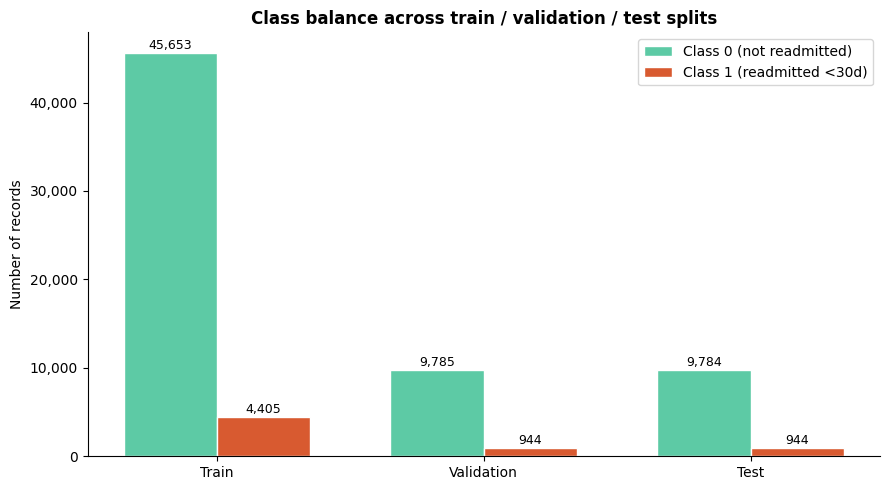

Plot saved: /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Results/NB01_class_balance.png
Summary table saved: /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Results/NB01_preprocessing_summary.csv

                                Step   Rows  Columns                                                                                 Notes
                         0. Raw data 101766       50                                                                  Original UCI dataset
               1. Replace ? with NaN 101766       50                                                                  ? → NaN in 7 columns
      2. Drop high-missing / ID cols 101766       31 Dropped: encounter_id, patient_nbr, weight, payer_code, medical_specialty, diag_1/2/3
3. Drop near-zero-variance drug cols 101766       20                                                Dropped 11 cols with 99-100% No values
 4. Keep first encounter per patient  71518       20                                   

In [13]:
# ── Plot: class balance across splits ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

split_names  = ['Train', 'Validation', 'Test']
class0_counts = [int((y_train==0).sum()), int((y_val==0).sum()), int((y_test==0).sum())]
class1_counts = [int((y_train==1).sum()), int((y_val==1).sum()), int((y_test==1).sum())]

x = np.arange(len(split_names))
w = 0.35

b0 = ax.bar(x - w/2, class0_counts, w, label='Class 0 (not readmitted)', color='#5DCAA5', edgecolor='white')
b1 = ax.bar(x + w/2, class1_counts, w, label='Class 1 (readmitted <30d)', color='#D85A30', edgecolor='white')

for bar in b0:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_ylabel('Number of records')
ax.set_title('Class balance across train / validation / test splits', fontsize=12, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_FOLDER + 'NB01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved:', RESULTS_FOLDER + 'NB01_class_balance.png')

# ── Summary table ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Step': [
        '0. Raw data',
        '1. Replace ? with NaN',
        '2. Drop high-missing / ID cols',
        '3. Drop near-zero-variance drug cols',
        '4. Keep first encounter per patient',
        '5. Remove 3 invalid-gender rows',
        '6. Binary target created',
        '7. Encode categoricals + scale',
        '8. Final train set',
        '9. Final val set',
        '10. Final test set'
    ],
    'Rows': [
        101766, 101766, 101766, 101766,
        71518, 71515, 71515, 71515,
        len(train_df), len(val_df), len(test_df)
    ],
    'Columns': [
        50, 50, 31, 20, 20, 20, 20,
        X_train.shape[1] + 1,
        train_df.shape[1], val_df.shape[1], test_df.shape[1]
    ],
    'Notes': [
        'Original UCI dataset',
        '? → NaN in 7 columns',
        'Dropped: encounter_id, patient_nbr, weight, payer_code, medical_specialty, diag_1/2/3',
        'Dropped 11 cols with 99-100% No values',
        'Sorted by encounter_id, kept first per patient_nbr',
        'Removed Unknown/Invalid gender (3 rows)',
        '<30 → 1, else → 0',
        'Age midpoints, drug ordinal, binary cols, OHE for race/glu/A1c, StandardScaler',
        '70% stratified split',
        '15% stratified split',
        '15% stratified split'
    ]
})

summary.to_csv(RESULTS_FOLDER + 'NB01_preprocessing_summary.csv', index=False)
print('Summary table saved:', RESULTS_FOLDER + 'NB01_preprocessing_summary.csv')
print()
print(summary.to_string(index=False))

---
## Section 14 — NB_01 Complete: Final checklist

Run this cell to verify everything succeeded before moving to NB_02.

In [14]:
checks = [
    ('train.csv saved',  os.path.exists(PROCESSED_FOLDER + 'train.csv')),
    ('val.csv saved',    os.path.exists(PROCESSED_FOLDER + 'val.csv')),
    ('test.csv saved',   os.path.exists(PROCESSED_FOLDER + 'test.csv')),
    ('No nulls in train', train_df.isnull().sum().sum() == 0),
    ('No nulls in val',   val_df.isnull().sum().sum()   == 0),
    ('No nulls in test',  test_df.isnull().sum().sum()  == 0),
    ('Target is binary',  set(train_df['readmitted_binary'].unique()) == {0, 1}),
    ('Plot saved', os.path.exists(RESULTS_FOLDER + 'NB01_class_balance.png')),
    ('Summary CSV saved', os.path.exists(RESULTS_FOLDER + 'NB01_preprocessing_summary.csv')),
]

print('NB_01 FINAL CHECKLIST')
print('=' * 40)
all_pass = True
for label, result in checks:
    icon = 'PASS' if result else 'FAIL'
    print(f'  [{icon}]  {label}')
    if not result:
        all_pass = False

print('=' * 40)
if all_pass:
    print('All checks passed. Ready for NB_02.')
else:
    print('Some checks FAILED. Scroll up and re-run the failing section.')

NB_01 FINAL CHECKLIST
  [PASS]  train.csv saved
  [PASS]  val.csv saved
  [PASS]  test.csv saved
  [PASS]  No nulls in train
  [PASS]  No nulls in val
  [PASS]  No nulls in test
  [PASS]  Target is binary
  [PASS]  Plot saved
  [PASS]  Summary CSV saved
All checks passed. Ready for NB_02.


---
## NB_01 Complete

You have successfully:
- Replaced `?` with `NaN` and identified which columns were heavily missing
- Dropped 19 useless or near-useless columns (IDs, high-missing, near-zero-variance drugs)
- Removed duplicate patient encounters (kept earliest visit per patient)
- Created the binary target: `readmitted_binary` (1 = readmitted within 30 days)
- Encoded all categorical columns using ordinal mapping, binary mapping, and one-hot encoding
- Scaled numeric features using StandardScaler (fitted on train only)
- Split into stratified 70/15/15 train/val/test sets
- Saved all three splits as CSV files to `Processed/`
- Saved a class balance plot and preprocessing summary to `Results/`

**Proceed to NB_02 — Central Baseline Model** when ready.